In [8]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("titanic")
data.head()
#data info
data.info()

#data description
data.describe()

#data shape
data.shape




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


(891, 15)

<Axes: xlabel='survived', ylabel='count'>

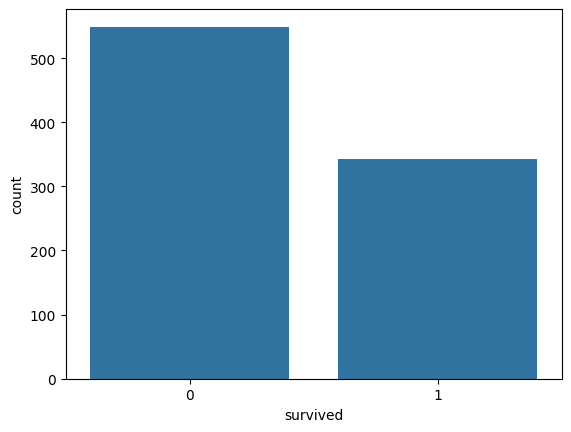

In [10]:
sns.countplot(
    data,
    x = "survived"
)

In [13]:
numeric = data.select_dtypes(include = ['number'])
numeric.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


<Axes: xlabel='fare', ylabel='Count'>

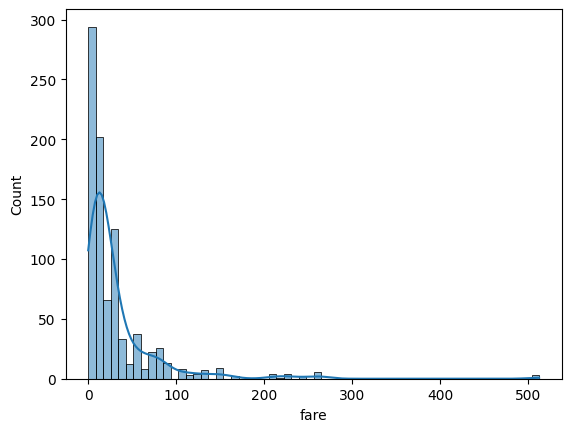

In [15]:
sns.histplot(
    numeric,
    x = "fare",
    kde = True
)

<Axes: xlabel='fare'>

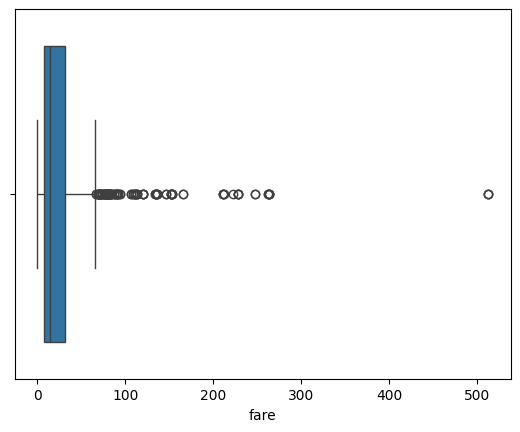

In [16]:
sns.boxplot(
    numeric,
    x = "fare"
)

In [22]:
#outlier detected
#approach 1: IQR to remove outliers

Q1 = np.quantile(numeric["fare"], 0.25)
Q3 = np.quantile(numeric["fare"], 0.75)

IQR = Q3 - Q1

lower = Q1 - 1.25 * IQR
upper = Q3 + 1.25 * IQR

outliers = numeric[
    (numeric["fare"] < lower) |
    (numeric["fare"] > upper)
    ]
outliers

,survived,pclass,age,sibsp,parch,fare
1,1,1,38.0,1,0,71.2833
27,0,1,19.0,3,2,263.0000
31,1,1,NaN,1,0,146.5208
34,0,1,28.0,1,0,82.1708
52,1,1,49.0,1,0,76.7292
...,...,...,...,...,...,...
846,0,3,NaN,8,2,69.5500
849,1,1,NaN,1,0,89.1042
856,1,1,45.0,1,1,164.8667
863,0,3,NaN,8,2,69.5500


In [23]:
#using z-score

from scipy.stats import zscore

numeric["fare_z"] = zscore(numeric["fare"].fillna(numeric["fare"].mean()))
outliers_from_z = numeric[
    abs(numeric['fare_z']) > 3
    ]
outliers_from_z

,survived,pclass,age,sibsp,parch,fare,fare_z
27,0,1,19.0,3,2,263.0000,4.647001
88,1,1,23.0,3,2,263.0000,4.647001
118,0,1,24.0,0,1,247.5208,4.335332
258,1,1,35.0,0,0,512.3292,9.667167
299,1,1,50.0,0,1,247.5208,4.335332
311,1,1,18.0,2,2,262.3750,4.634417
341,1,1,24.0,3,2,263.0000,4.647001
377,0,1,27.0,0,2,211.5000,3.610065
380,1,1,42.0,0,0,227.5250,3.932723
438,0,1,64.0,1,4,263.0000,4.647001


In [24]:
#correlation heatmap
corr = numeric.corr()
corr

,survived,pclass,age,sibsp,parch,fare,fare_z
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,1.000000
fare_z,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,1.000000


<Axes: >

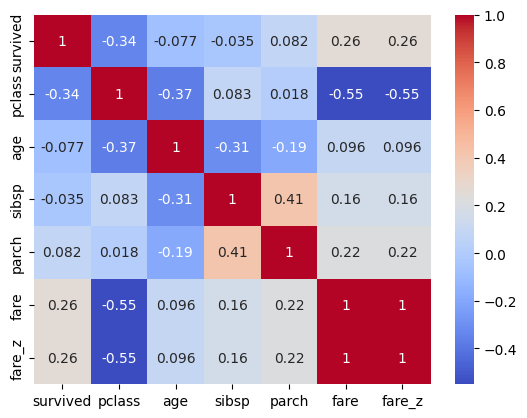

In [25]:
sns.heatmap(
    corr,
    cmap = "coolwarm",
    annot = True,
)

In [ ]:
#top 3 features correlated with the target is
#1. pclass
#2. fare
#3. parch
